# Importing Libraries

In [1]:
import pandas as pd
import numpy as np

import os
import sys

import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from IPython.display import Audio

import tensorflow as tf
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Attention, GlobalAveragePooling1D
from tensorflow.keras.models import Model
# For Functional
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, BatchNormalization

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Dataset

In [4]:
Crema ="C:\\Users\\vinshul jain\\Downloads\\archive (1)\\AudioWAV\\"  

In [6]:
crema_directory_list = os.listdir(Crema)

file_emotion = []
file_path = []

for file in crema_directory_list:
    # storing file paths
    file_path.append(Crema + file)
    # storing file emotions
    part=file.split('_')
    if part[2] == 'SAD':
        file_emotion.append('sad')
    elif part[2] == 'ANG':
        file_emotion.append('angry')
    elif part[2] == 'DIS':
        file_emotion.append('disgust')
    elif part[2] == 'FEA':
        file_emotion.append('fear')
    elif part[2] == 'HAP':
        file_emotion.append('happy')
    elif part[2] == 'NEU':
        file_emotion.append('neutral')
    else:
        file_emotion.append('Unknown')
        
# dataframe for emotion of files
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

# dataframe for path of files.
path_df = pd.DataFrame(file_path, columns=['Path'])
Crema_df = pd.concat([emotion_df, path_df], axis=1)
Crema_df.head()

,Emotions,Path
0,angry,C:\Users\vinshul jain\Downloads\archive (1)\Au...
1,disgust,C:\Users\vinshul jain\Downloads\archive (1)\Au...
2,fear,C:\Users\vinshul jain\Downloads\archive (1)\Au...
3,happy,C:\Users\vinshul jain\Downloads\archive (1)\Au...
4,neutral,C:\Users\vinshul jain\Downloads\archive (1)\Au...


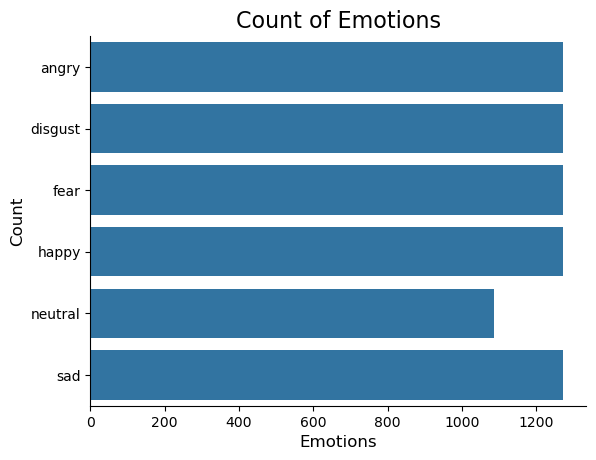

In [8]:
plt.title('Count of Emotions', size=16)
sns.countplot(Crema_df.Emotions)
plt.ylabel('Count', size=12)
plt.xlabel('Emotions', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.show()

# Visualization

In [11]:
def create_waveplot(data, sr, e):
    plt.figure(figsize=(10, 3))
    plt.title('Waveplot for {} emotion'.format(e), size=15)
    librosa.display.waveshow(data, sr=sr)
    plt.show()

def create_spectrogram(data, sr, e):
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(12, 3))
    plt.title('Spectrogram for {} emotion'.format(e), size=15)
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')   
    plt.colorbar()

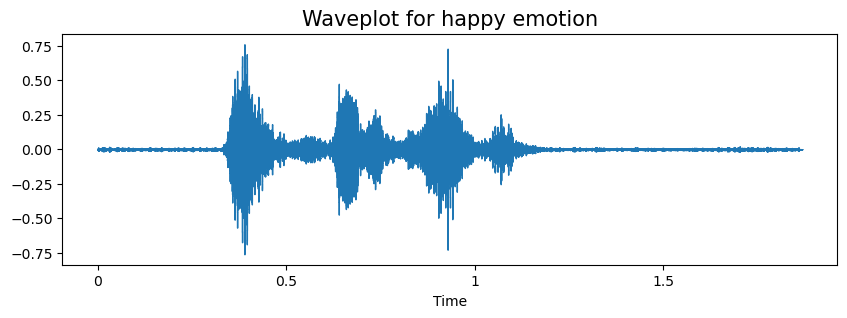

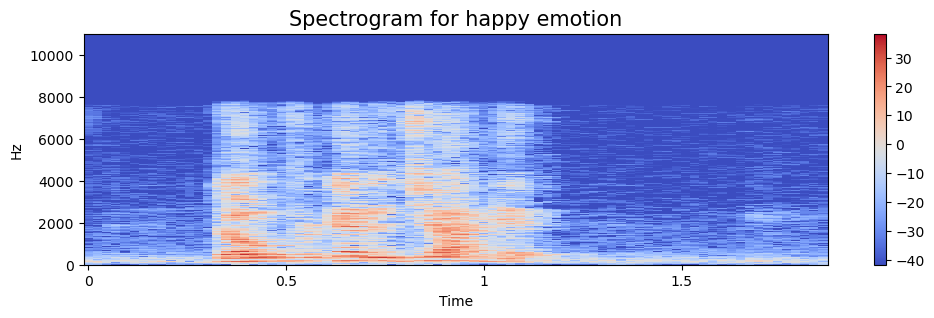

In [13]:
emotion='happy'
path = np.array(Crema_df.Path[Crema_df.Emotions==emotion])[0]
data, sampling_rate = librosa.load(path)
create_waveplot(data, sampling_rate, emotion)
create_spectrogram(data, sampling_rate, emotion)
Audio(path)

# MFCC Extraction

In [15]:
labels = {'disgust':0,'happy':1,'sad':2,'neutral':3,'fear':4,'angry':5}
Crema_df.replace({'Emotions':labels},inplace=True)

In [18]:
num_mfcc=13
n_fft=2048
hop_length=512
SAMPLE_RATE = 22050
data = {
        "labels": [],
        "mfcc": []
    }
for i in range(7442):
    data['labels'].append(Crema_df.iloc[i,0])
    signal, sample_rate = librosa.load(Crema_df.iloc[i,1], sr=SAMPLE_RATE)
    mfcc = librosa.feature.mfcc(y=signal, sr=sample_rate, n_mfcc=13, n_fft=2048, hop_length=512)
    mfcc = mfcc.T
    data["mfcc"].append(np.asarray(mfcc))
    if i%500==0:
        print(i)

0
500
1000
1500
2000
2500
3000
3500
4000
4500
5000
5500
6000
6500
7000


# Padding MFCC to make them of equal length

In [20]:
# Define a fixed length for MFCC sequences (e.g., 100 frames)
max_length = 200

# Function to pad or truncate sequences
def pad_mfcc(mfcc, max_length):
    if len(mfcc) < max_length:
        # Pad with zeros
        padding = max_length - len(mfcc)
        mfcc = np.pad(mfcc, ((0, padding), (0, 0)), mode='constant', constant_values=0)
    else:
        # Truncate to max_length
        mfcc = mfcc[:max_length]
    return mfcc

# Apply padding/truncation to all MFCC sequences
data['mfcc'] = [pad_mfcc(mfcc, max_length) for mfcc in data['mfcc']]

# Convert to NumPy array
X = np.asarray(data['mfcc'])
y = np.asarray(data["labels"])

In [21]:
X = tf.keras.preprocessing.sequence.pad_sequences(X)
X.shape

(7442, 200, 13)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)
X_train, X_validation, y_train, y_validation = train_test_split(X_train, y_train, test_size=0.2)

In [23]:
print(X_train.shape,y_train.shape,X_validation.shape,y_validation.shape,X_test.shape,y_test.shape)

(5357, 200, 13) (5357,) (1340, 200, 13) (1340,) (745, 200, 13) (745,)


# Sequential Model

In [30]:
def build_cnn_lstm_model(input_shape):
    model = tf.keras.Sequential()

    # CNN layers
    model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.1))

    model.add(Conv1D(128, kernel_size=3, activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.1))

    # LSTM layers
    model.add(LSTM(128, return_sequences=True))
    model.add(LSTM(64))

    # Dense layers
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(6, activation='softmax'))  # 6 emotions

    return model

# Create the model
input_shape = (X_train.shape[1], X_train.shape[2])  # (time_steps, features)
model = build_cnn_lstm_model(input_shape)

# Compile the model
optimiser = tf.keras.optimizers.Adam(learning_rate=0.0005)  # Reduced LR for stability
model.compile(optimizer=optimiser, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 198, 64)             │           2,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 198, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 99, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 99, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 97, 128)             │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 97, 128)             │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 48, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 48, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 48, 128)             │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             390 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 213,574 (834.27 KB)

 Trainable params: 213,190 (832.77 KB)

 Non-trainable params: 384 (1.50 KB)

# Training

In [32]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_validation, y_validation),
    batch_size=32,
    epochs=50
)


Epoch 1/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 29s 100ms/step - accuracy: 0.1673 - loss: 1.8002 - val_accuracy: 0.3388 - val_loss: 1.6152
Epoch 2/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.3155 - loss: 1.6058 - val_accuracy: 0.3791 - val_loss: 1.4845
Epoch 3/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 15s 91ms/step - accuracy: 0.3658 - loss: 1.4982 - val_accuracy: 0.4075 - val_loss: 1.4282
Epoch 4/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.4098 - loss: 1.4577 - val_accuracy: 0.4366 - val_loss: 1.4106
Epoch 5/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 15s 90ms/step - accuracy: 0.4362 - loss: 1.4232 - val_accuracy: 0.4545 - val_loss: 1.3934
Epoch 6/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 15s 92ms/step - accuracy: 0.4602 - loss: 1.3628 - val_accuracy: 0.4224 - val_loss: 1.4007
Epoch 7/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 16s 92ms/step - accuracy: 0.4645 - loss: 1.3449 - val_accuracy: 0.4761 - val_loss: 1.3323
Epoch 8/50
168/168 ━━━━━━━━━━━━━━━━━━━━ 16s 93ms/step - accuracy: 0.4785 - loss: 1.3160 -

# Evaluation

In [37]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy: ",test_acc)

Test Accuracy:  0.5946308970451355


# Functional Model

In [26]:
def build_attention_lstm_model_fixed(input_shape):
    inputs = Input(shape=input_shape)
    
    # LSTM Layers
    lstm_out = LSTM(128, return_sequences=True)(inputs)
    lstm_out = Dropout(0.2)(lstm_out)
    
    lstm_out = LSTM(64, return_sequences=True)(lstm_out)
    lstm_out = Dropout(0.2)(lstm_out)
    
    # Attention Layer
    attention_query = Dense(64, activation='tanh')(lstm_out)
    attention_out = Attention()([attention_query, lstm_out])
    
    # Global Average Pooling to reduce sequence dimension
    pooled_output = GlobalAveragePooling1D()(attention_out)
    
    # Fully Connected Layers
    dense_out = Dense(64, activation='relu')(pooled_output)
    dense_out = Dropout(0.2)(dense_out)
    outputs = Dense(6, activation='softmax')(dense_out)
    
    model_1 = Model(inputs=inputs, outputs=outputs)
    return model_1

# Build and Compile Model
input_shape = (X_train.shape[1], X_train.shape[2])  # (time_steps, features)
attention_lstm_model_fixed = build_attention_lstm_model_fixed(input_shape)

attention_lstm_model_fixed.compile(optimizer='adam',
                                   loss='sparse_categorical_crossentropy',
                                   metrics=['accuracy'])

attention_lstm_model_fixed.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 200, 13)           │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 200, 128)          │          72,704 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 200, 128)          │               0 │ lstm[0][0]                 │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, 200, 64)           │          49,408 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 200, 64)           │               0 │ lstm_1[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 200, 64)           │           4,160 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention (Attention)         │ (None, 200, 64)           │               0 │ dense[0][0],               │
│                               │                           │                 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_average_pooling1d      │ (None, 64)                │               0 │ attention[0][0]            │
│ (GlobalAveragePooling1D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           4,160 │ global_average_pooling1d[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 64)                │               0 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 6)                 │             390 │ dropout_2[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 130,822 (511.02 KB)

 Trainable params: 130,822 (511.02 KB)

 Non-trainable params: 0 (0.00 B)

# Training

In [28]:
# Train Model
attention_lstm_history_fixed = attention_lstm_model_fixed.fit(
    X_train, y_train,
    validation_data=(X_validation, y_validation),
    batch_size=32, epochs=30
)


Epoch 1/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 71s 379ms/step - accuracy: 0.3380 - loss: 1.5765 - val_accuracy: 0.3925 - val_loss: 1.4339
Epoch 2/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 77s 349ms/step - accuracy: 0.4210 - loss: 1.4096 - val_accuracy: 0.4493 - val_loss: 1.3506
Epoch 3/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 63s 377ms/step - accuracy: 0.4581 - loss: 1.3534 - val_accuracy: 0.4724 - val_loss: 1.3200
Epoch 4/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 77s 348ms/step - accuracy: 0.5028 - loss: 1.2869 - val_accuracy: 0.4396 - val_loss: 1.3698
Epoch 5/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 82s 349ms/step - accuracy: 0.4940 - loss: 1.2620 - val_accuracy: 0.4940 - val_loss: 1.2708
Epoch 6/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 64s 381ms/step - accuracy: 0.5249 - loss: 1.2195 - val_accuracy: 0.5127 - val_loss: 1.2458
Epoch 7/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 64s 379ms/step - accuracy: 0.5449 - loss: 1.1893 - val_accuracy: 0.5194 - val_loss: 1.2121
Epoch 8/30
168/168 ━━━━━━━━━━━━━━━━━━━━ 76s 347ms/step - accuracy: 0.5294 - loss: 1

# Evaluation

In [58]:
test_loss, test_acc = attention_lstm_model_fixed.evaluate(X_test, y_test, verbose=0)

In [62]:
print("Test Accuracy: ",test_acc)

Test Accuracy:  64.27700890102034


In [60]:
test_acc=64.27700890102034

In [54]:
def preprocess_audio(file_path, num_mfcc=13, n_fft=2048, hop_length=512, sample_rate=22050):
    # Load the audio file
    signal, sample_rate = librosa.load(file_path, sr=sample_rate)
    
    # Extract MFCC features
    mfcc = librosa.feature.mfcc(y=signal, sr=sample_rate, n_mfcc=num_mfcc, n_fft=n_fft, hop_length=hop_length)
    
    # Transpose the MFCC to mhatch the input shape (time steps, MFCC coefficients)
    mfcc = mfcc.T
    
    # Pad the MFCC features to match the input shape of the model
    mfcc = tf.keras.preprocessing.sequence.pad_sequences([mfcc], maxlen=X.shape[1], padding='post')
    
    return np.array(mfcc)

# Testing by Sequential Model

In [49]:
def predict_emotion(model, file_path):
    # Preprocess the audio file
    mfcc = preprocess_audio(file_path)
    
    # Make a prediction
    prediction = model.predict(mfcc)
    
    # Get the index with the highest probability
    predicted_index = np.argmax(prediction, axis=1)
    
    return predicted_index[0]

In [70]:
# Define the mapping from label to emotion
labels_to_emotions = {0: 'disgust 🤢', 1: 'happy 😂', 2: 'sad 😔', 3: 'neutral 🙂', 4: 'fear 😧', 5: 'angry 😡'}
# Example: Path to your pre-recorded audio file
file_path ="C:\\Users\\vinshul jain\\Downloads\\archive (1)\\AudioWAV\\1001_DFA_ANG_XX.wav" # Replace with the actual file path

# Predict the emotion
predicted_label = predict_emotion(model, file_path)
predicted_emotion = labels_to_emotions[predicted_label]

print("Predicted Emotion: ", predicted_emotion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predicted Emotion:  angry 😡


# Testing by Functional Model

In [64]:
def predict_emotion(model1, file_path):
    # Preprocess the audio file
    mfcc = preprocess_audio(file_path)
    
    # Make a prediction
    prediction = model.predict(mfcc)
    
    # Get the index with the highest probability
    predicted_index = np.argmax(prediction, axis=1)
    
    return predicted_index[0]

In [89]:
# Define the mapping from label to emotion
labels_to_emotions = {0: 'disgust 🤢', 1: 'happy 😂', 2: 'sad 😔', 3: 'neutral 🙂', 4: 'fear 😧', 5: 'angry 😡'}
# Example: Path to your pre-recorded audio file
file_path ="C:\\Users\\vinshul jain\\Downloads\\archive (1)\\AudioWAV\\1001_DFA_ANG_XX.wav" # Replace with the actual file path

# Predict the emotion
predicted_label = predict_emotion(model, file_path)
predicted_emotion = labels_to_emotions[predicted_label]

print("Predicted Emotion: ", predicted_emotion)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Emotion:  fear 😧
